In [1]:
import pandas as pd

def filter_smiles_with_F(input_csv: str, output_csv: str):
    # CSVファイルを読み込み
    df = pd.read_csv(input_csv)
    
    # smiles列に 'F' を含む行をフィルタ
    df_with_F = df[df['smiles'].str.contains('F')]

    # 結果を出力
    df_with_F.to_csv(output_csv, index=False)
    print(f"{len(df_with_F)} 件のFを含む分子を {output_csv} に保存しました。")

# 使用例
filter_smiles_with_F('../data/stats/similarity_results_dedup.csv', '../data/stats/similarity_exists_F.csv')


164 件のFを含む分子を ../data/stats/similarity_exists_F.csv に保存しました。


Filtered 4 molecules with w_similarity < 0.1
Filtered data has only 4 entries, which is less than PRINT_LIM (20). Displaying all.


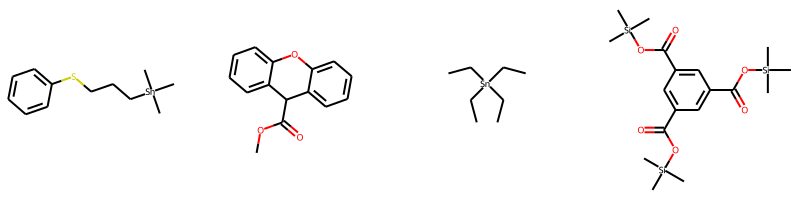

In [12]:
# w_similarity<Xを満たすsmilesを抽出、構造式を描画

import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image  # 追加！
import random

def display_structures_below_threshold(input_csv: str, threshold: float, max_mols: int = 12):
    # CSVの読み込み
    df = pd.read_csv(input_csv)

    # w_similarity が閾値未満の行を抽出
    filtered_df = df[df['w_similarity'] < threshold]

    len_filtered = len(filtered_df)
    print(f"Filtered {len_filtered} molecules with w_similarity < {threshold}")

    PRINT_LIM = 20
    counter = 0

    # 0<= x < len_filteredの範囲でPRINT_LIM個の数値をランダムに選ぶ
    if len_filtered < PRINT_LIM:
        print(f"Filtered data has only {len_filtered} entries, which is less than PRINT_LIM ({PRINT_LIM}). Displaying all.")
        max_mols = len_filtered
    else:
        print(f"Displaying up to {PRINT_LIM} random entries from the filtered data.")
        random_indices = random.sample(range(len_filtered), min(PRINT_LIM, len_filtered))
        filtered_df = filtered_df.iloc[random_indices]
        print(f"Selected {len(filtered_df)} random entries for display.")

    # SMILES を RDKit の Mol に変換（None除去）
    mols = []
    for smi in filtered_df['smiles']:
        counter += 1
        if counter > PRINT_LIM:
            print(f"Processed {counter} SMILES, stopping early to avoid excessive output.")
            break
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            mols.append(mol)
        else:
            print(f"Invalid SMILES: {smi}")

    # 上限数を制限（多すぎると表示が乱れるので）
    mols_to_show = mols[:max_mols]

    # 構造式をグリッド表示
    img = Draw.MolsToGridImage(mols_to_show, molsPerRow=4, subImgSize=(200, 200))
    display(img)

# 使用例
display_structures_below_threshold('../data/stats/similarity_results_dedup.csv', threshold=0.1)
